# Descrição original

Vou manter só as partes que interessam, como a descrição dos dados e seus contextos.
Vai ficar em inglês mesmo.

##  Bank Marketing

**Abstract:** 
The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).

**Data Set Information:**
The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. 

###  Attribute Information:

####  Bank client data:

 - Age (numeric)
 - Job : type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
 - Marital : marital status (categorical: 'divorced', 'married', 'single', 'unknown' ; note: 'divorced' means divorced or widowed)
 - Education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',  'illiterate', 'professional.course', 'university.degree', 'unknown')
 - Default: has credit in default? (categorical: 'no', 'yes', 'unknown')
 - Housing: has housing loan? (categorical: 'no', 'yes', 'unknown')
 - Loan: has personal loan? (categorical: 'no', 'yes', 'unknown')

    
####  Related with the last contact of the current campaign:

 - Contact: contact communication type (categorical:
   'cellular','telephone')
 - Month: last contact month of year (categorical: 'jan', 'feb', 'mar',
   ..., 'nov', 'dec')
 - Day_of_week: last contact day of the week (categorical:
   'mon','tue','wed','thu','fri')
 - Duration: last contact duration, in seconds (numeric). Important
   note: this attribute highly affects the output target (e.g., if
   duration=0 then y='no'). Yet, the duration is not known before a call
   is performed. Also, after the end of the call y is obviously known.
   Thus, this input should only be included for benchmark purposes and
   should be discarded if the intention is to have a realistic
   predictive model.

    
####  Other attributes:

 - Campaign: number of contacts performed during this campaign and for
   this client (numeric, includes last contact)
 - Pdays: number of days that passed by after the client was last
   contacted from a previous campaign (numeric; 999 means client was not
   previously contacted)
 - Previous: number of contacts performed before this campaign and for
   this client (numeric)
 - Poutcome: outcome of the previous marketing campaign (categorical:
   'failure','nonexistent','success')

    
####  Social and economic context attributes
 - Emp.var.rate: employment variation rate - quarterly indicator
   (numeric)
 - Cons.price.idx: consumer price index - monthly indicator (numeric)
 - Cons.conf.idx: consumer confidence index - monthly indicator
   (numeric)
 - Euribor3m: euribor 3 month rate - daily indicator (numeric)
 - Nr.employed: number of employees - quarterly indicator (numeric)

####  Output variable (desired target):

 - y - has the client subscribed a term deposit? (binary: 'yes', 'no')

     
###  Source:

 - Dataset from : http://archive.ics.uci.edu/ml/datasets/Bank+Marketing#


In [25]:
# Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [26]:
bank = pd.read_csv('../raw/bank-additional-full.csv', sep = ';')
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [27]:
bank.info()
bank.describe().map(lambda x: f"{x:0.2f}")

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


#### Para adaptar a base ao contexto de produtos digitais em web, removemos as colunas de histórico de contato telefônico que não fazem sentido nesse cenário: `duration`, `campaign`, `pdays`, `previous` e `poutcome`.

In [28]:
# Remove campos de histórico de contato telefônico que não são relevantes para um ambiente digital
bank = bank.drop(columns=['duration', 'campaign', 'pdays', 'previous', 'poutcome', 'contact'])
bank.head()

,age,job,marital,education,default,housing,loan,month,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,may,mon,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,may,mon,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,may,mon,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,may,mon,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,may,mon,1.1,93.994,-36.4,4.857,5191.0,no


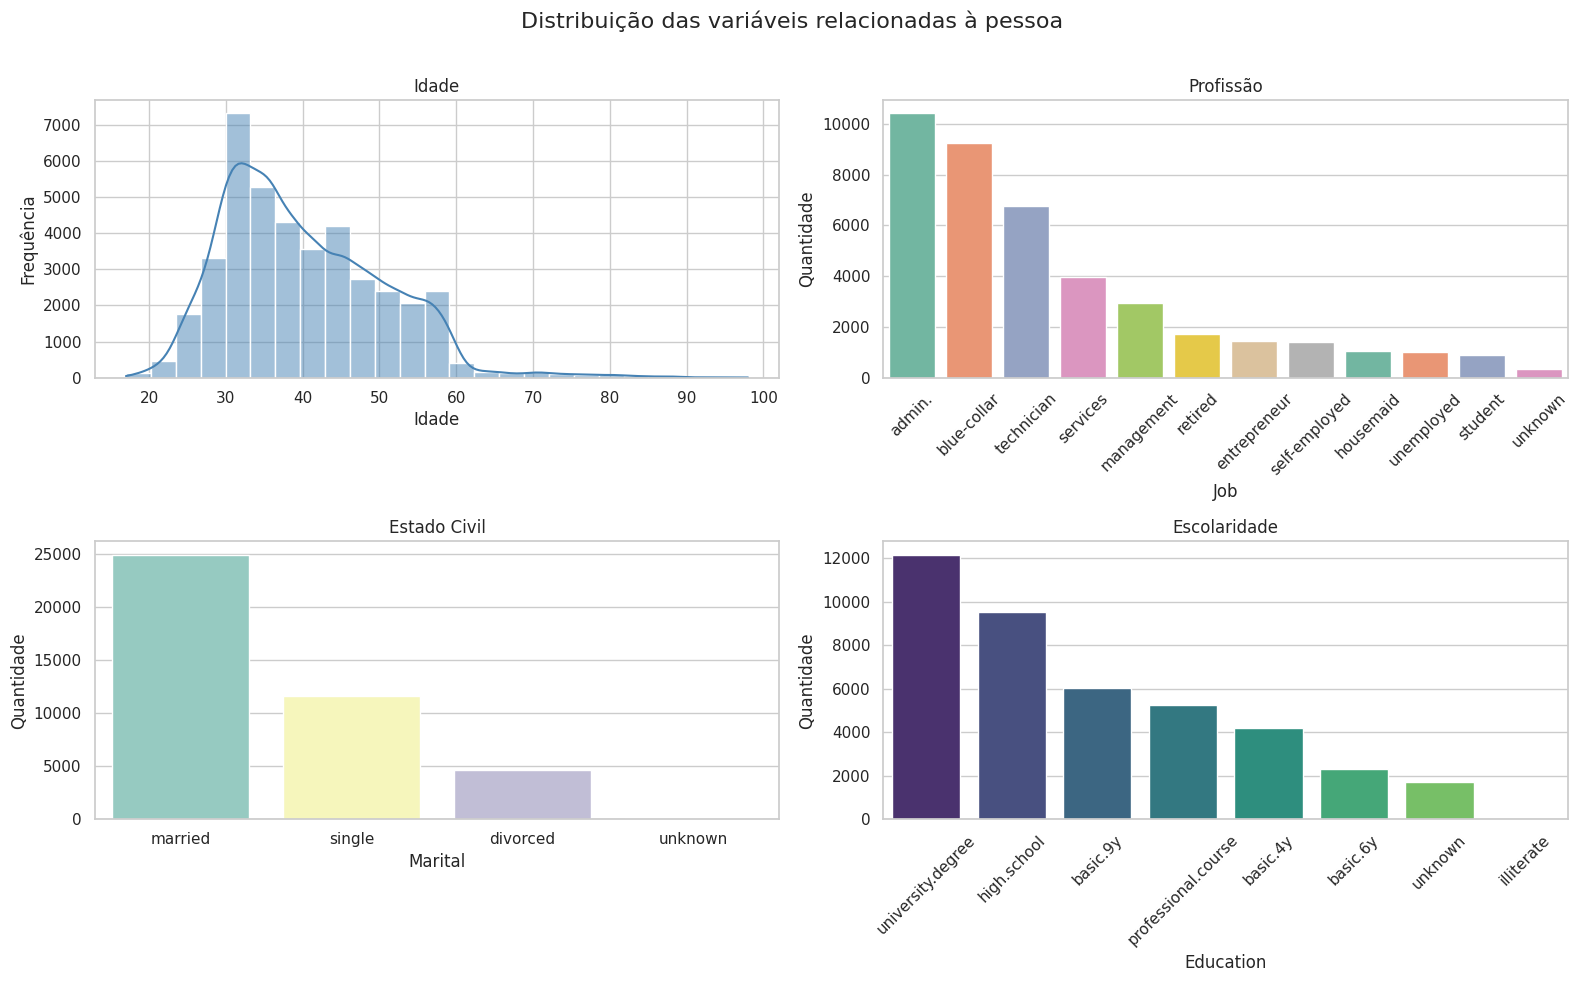

In [29]:
# Distribuição das 4 primeiras variáveis relacionadas à pessoa
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuição das variáveis relacionadas à pessoa', fontsize=16)

# Idade
sns.histplot(bank['age'], bins=25, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Idade')
axes[0, 0].set_xlabel('Idade')
axes[0, 0].set_ylabel('Frequência')

# Profissão
sns.countplot(data=bank, x='job', ax=axes[0, 1], order=bank['job'].value_counts().index, palette='Set2')
axes[0, 1].set_title('Profissão')
axes[0, 1].set_xlabel('Job')
axes[0, 1].set_ylabel('Quantidade')
axes[0, 1].tick_params(axis='x', rotation=45)

# Estado civil
sns.countplot(data=bank, x='marital', ax=axes[1, 0], order=bank['marital'].value_counts().index, palette='Set3')
axes[1, 0].set_title('Estado Civil')
axes[1, 0].set_xlabel('Marital')
axes[1, 0].set_ylabel('Quantidade')

# Escolaridade
sns.countplot(data=bank, x='education', ax=axes[1, 1], order=bank['education'].value_counts().index, palette='viridis')
axes[1, 1].set_title('Escolaridade')
axes[1, 1].set_xlabel('Education')
axes[1, 1].set_ylabel('Quantidade')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

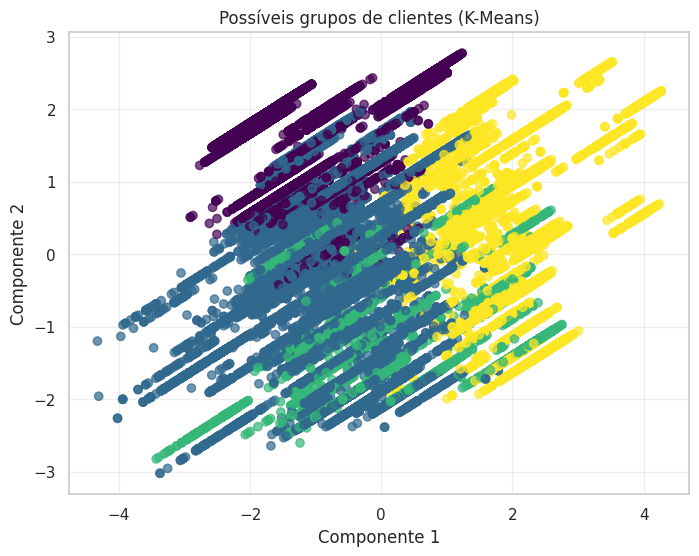

y,taxa_yes,taxa_no
cluster,,
3,0.149000,0.851000
1,0.116895,0.883105
2,0.111581,0.888419
0,0.066546,0.933454


In [30]:
# Visualização de possíveis grupos com clustering (K-Means)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

features = ['age', 'job', 'marital', 'education']
X = pd.get_dummies(bank[features], columns=['job', 'marital', 'education'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title('Possíveis grupos de clientes (K-Means)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.grid(True, alpha=0.3)
plt.show()

# Comparando clusters com a variável alvo para avaliar potencial de conversão
bank['cluster'] = labels
cluster_conversion = bank.groupby('cluster')['y'].value_counts(normalize=True).unstack().fillna(0)
cluster_conversion = cluster_conversion.rename(columns={'yes': 'taxa_yes', 'no': 'taxa_no'})
cluster_conversion['taxa_yes'] = cluster_conversion.get('taxa_yes', 0)
cluster_conversion['taxa_no'] = cluster_conversion.get('taxa_no', 0)
cluster_conversion[['taxa_yes', 'taxa_no']].sort_values('taxa_yes', ascending=False)

#### Tentei verificar aqui se só com os dados mais simples das pessoas já era possível identificar grupos disitintos e boas taxas de conversão, mas é tudo muito próximo e mesclado.
#### Vou utilizar os dados completos provavelmente para treinar o modelo.

#### K-neighbourhood (contexto social e econômico)
Esta célula calcula os vizinhos mais próximos com base nos indicadores sociais e econômicos, plota um gráfico de cotovelo para ajudar a escolher o valor de k e visualiza as vizinhanças no espaço do PCA com alguns pontos de referência.

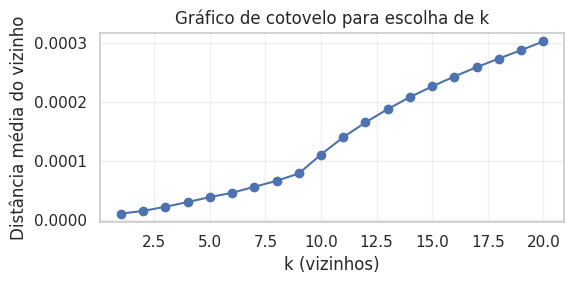

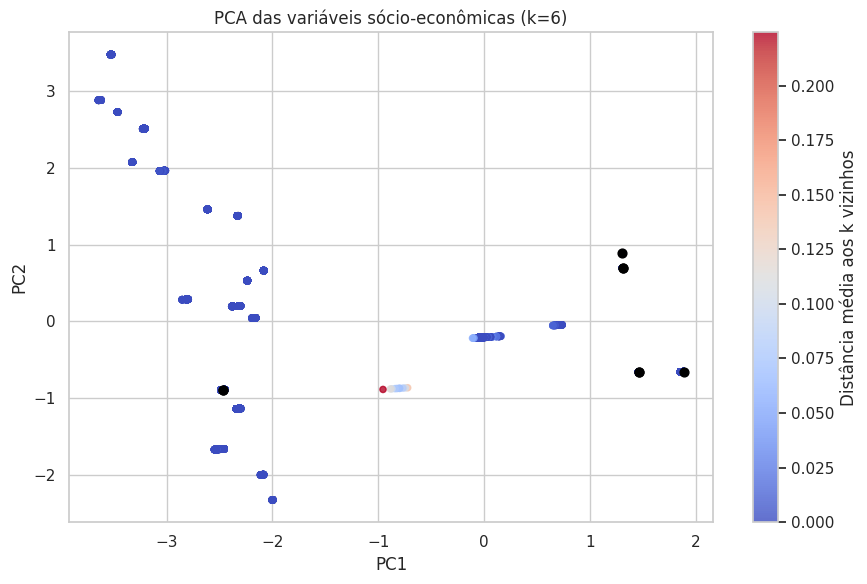

In [31]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Features: contexto social e econômico
features_kn = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df_kn = bank[features_kn].dropna().reset_index(drop=True)

# Padronização
scaler_kn = StandardScaler()
X_kn = scaler_kn.fit_transform(df_kn)

# PCA para visualização
pca_kn = PCA(n_components=2)
Xp_kn = pca_kn.fit_transform(X_kn)

# Calcular distâncias entre vizinhos para diferentes valores de k e analisar o comportamento
max_k = 20
avg_dist = []
for k in range(1, max_k + 1):
  nbrs_k = NearestNeighbors(n_neighbors=k + 1).fit(X_kn)
  dists_k, _ = nbrs_k.kneighbors(X_kn)
  # ignorar a própria observação na primeira coluna quando k+1 inclui o próprio ponto
  avg_dist.append(dists_k[:, 1:].mean())

plt.figure(figsize=(6, 3))
plt.plot(range(1, max_k + 1), avg_dist, marker='o')
plt.xlabel('k (vizinhos)')
plt.ylabel('Distância média do vizinho')
plt.title('Gráfico de cotovelo para escolha de k')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Escolher k (exemplo: 6)
k = 6
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_kn)
dists, inds = nbrs.kneighbors(X_kn)

# ignorar o próprio ponto na primeira coluna
dists_noself = dists[:, 1:]
inds_noself = inds[:, 1:]
avg_dist_point = dists_noself.mean(axis=1)

# Visualizar a dispersão do PCA colorida pela distância média (densidade local)
plt.figure(figsize=(9, 6))
sc = plt.scatter(Xp_kn[:, 0], Xp_kn[:, 1], c=avg_dist_point, cmap='coolwarm', s=20, alpha=0.8)
plt.colorbar(sc, label='Distância média aos k vizinhos')
plt.title(f'PCA das variáveis sócio-econômicas (k={k})')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Desenhar vizinhanças para alguns pontos de referência aleatórios
np.random.seed(42)
sample_idx = np.random.choice(len(Xp_kn), size=8, replace=False)
for idx in sample_idx:
  neigh_idx = inds_noself[idx]
  for n in neigh_idx:
    plt.plot([Xp_kn[idx, 0], Xp_kn[n, 0]], [Xp_kn[idx, 1], Xp_kn[n, 1]], color='gray', linewidth=0.6, alpha=0.6)
  plt.scatter(Xp_kn[idx, 0], Xp_kn[idx, 1], color='black', s=40)

plt.tight_layout()
plt.show()

# Resumir grupos tipo clusters por binagem da distância média
import pandas as pd
summary = pd.DataFrame({
  'pc1': Xp_kn[:, 0], 'pc2': Xp_kn[:, 1], 'avg_dist_k': avg_dist_point
})

#### Análise dos clusters (centros e amostras)
Esta célula aplica KMeans sobre as variáveis sócio-econômicas, calcula os centros em unidades originais, mostra o tamanho de cada cluster, as taxas de conversão e exibe amostras do cluster com maior taxa de `yes`.

In [32]:
from sklearn.cluster import KMeans

# Reconstruir o DataFrame alinhado aos índices originais para preservar a variável alvo 'y'
df_kn_full = bank[features_kn + ['y']].dropna().copy()
X_full = scaler_kn.transform(df_kn_full[features_kn])

# KMeans nas características sócio-econômicas
n_clusters = 4
kmeans_kn = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X_full)
labels_kn = kmeans_kn.labels_

# Centros no espaço escalado -> transformar de volta para unidades originais
centers_scaled = kmeans_kn.cluster_centers_
centers_orig = scaler_kn.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_orig, columns=features_kn)

print('Centros dos clusters (unidades originais):')
display(centers_df)

# Adicionar rótulos ao DataFrame e calcular tamanhos + taxas de conversão
df_kn_full['kcluster'] = labels_kn
counts = df_kn_full['kcluster'].value_counts().sort_index()
conv = df_kn_full.groupby('kcluster')['y'].value_counts(normalize=True).unstack().fillna(0)

print('\nTamanhos dos clusters:')
print(counts)
print('\nTaxas de conversão por cluster do KMeans (proporção yes/no):')
print(conv)

# Identificar o cluster com maior taxa de 'yes'
if 'yes' in conv.columns:
    best_cluster = conv['yes'].idxmax()
    print(f"\nCluster com maior conversão: {best_cluster}")
    print('\nCentro (unidades originais) deste cluster:')
    display(centers_df.loc[best_cluster:best_cluster])

    # Mostrar algumas linhas do DataFrame original que pertencem a esse cluster
    sample_rows = df_kn_full[df_kn_full['kcluster'] == best_cluster].head(10)
    print('\nExemplos de linhas do melhor cluster (primeiras 10):')
    display(sample_rows)
else:
    print('Nenhuma classe positiva "yes" foi encontrada na tabela de conversão.')

Centros dos clusters (unidades originais):


,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.927501,93.649226,-37.541032,4.729694,5203.614819
1,-1.822861,93.133446,-45.426960,1.264261,5080.356889
2,-2.926968,92.590404,-31.102701,0.779150,5037.593267
3,1.400000,94.134347,-42.344037,4.949742,5228.100000



Tamanhos dos clusters:
kcluster
0    16621
1    10879
2     2629
3    11059
Name: count, dtype: int64

Taxas de conversão por cluster do KMeans (proporção yes/no):
y               no       yes
kcluster                    
0         0.955298  0.044702
1         0.799338  0.200662
2         0.574363  0.425637
3         0.946198  0.053802

Cluster com maior conversão: 2

Centro (unidades originais) deste cluster:


,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
2,-2.926968,92.590404,-31.102701,0.77915,5037.593267



Exemplos de linhas do melhor cluster (primeiras 10):


,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,kcluster
36939,-2.9,92.469,-33.6,1.085,5076.2,yes,2
36940,-2.9,92.469,-33.6,1.085,5076.2,no,2
36941,-2.9,92.469,-33.6,1.085,5076.2,no,2
36942,-2.9,92.469,-33.6,1.085,5076.2,no,2
36943,-2.9,92.469,-33.6,1.085,5076.2,yes,2
36944,-2.9,92.469,-33.6,1.085,5076.2,yes,2
36945,-2.9,92.469,-33.6,1.085,5076.2,yes,2
36946,-2.9,92.469,-33.6,1.072,5076.2,yes,2
36947,-2.9,92.469,-33.6,1.072,5076.2,no,2
36948,-2.9,92.469,-33.6,1.072,5076.2,no,2


In [33]:
# Valores únicos de cons.conf.idx
bank['cons.conf.idx'].unique()

array([-36.4, -41.8, -42.7, -36.1, -40.4, -42. , -45.9, -50. , -47.1,
       -46.2, -40.8, -33.6, -31.4, -29.8, -26.9, -30.1, -33. , -34.8,
       -34.6, -40. , -39.8, -40.3, -38.3, -37.5, -49.5, -50.8])

#### Esse indice de confiança parece influenciar bastante, mas não entendi 100% o que ele demonstra com valores negativos.

#### Okay, fiz uma pesquisa rápida no google e parece que é um balanço de pessimos vs otimismo. Nesse caso então, como só temos um numero negativo, podemos assumir que o quão pessimista os clientes do banco estão.

#### Provalmente na fase de geração sintética vou ter que ficar de olho nesses valores.

In [36]:
data_dictionary = {
'age': 'Idade do cliente (numérico)',
'job': 'Tipo de emprego (categórico)',
'marital': 'Estado civil (categórico)',
'education': 'Nível de escolaridade (categórico)',
'default': 'Possui crédito em inadimplência? (categórico)',
'housing': 'Possui empréstimo habitacional? (categórico)',
'loan': 'Possui empréstimo pessoal? (categórico)',
'month': 'Mês do último contato (categórico)',
'day_of_week': 'Dia da semana do último contato (categórico)',
'emp.var.rate': 'Taxa de variação do emprego (numérico)',
'cons.price.idx': 'Índice de preços ao consumidor (numérico)',
'cons.conf.idx': 'Índice de confiança do consumidor (numérico)',
'euribor3m': 'Taxa Euribor de 3 meses (numérico)',
'nr.employed': 'Número de empregados (numérico)',
'y': 'Cliente aderiu ao depósito a prazo? (alvo)',
'cluster': 'Rótulo de cluster do KMeans aplicado às características pessoais'
}

print('Colunas do dataframe:')
print(bank.columns.tolist())

print('\nDicionário de dados:')
for col, desc in data_dictionary.items():
    print(f'- {col}: {desc}')

Colunas do dataframe:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'day_of_week', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'cluster']

Dicionário de dados:
- age: Idade do cliente (numérico)
- job: Tipo de emprego (categórico)
- marital: Estado civil (categórico)
- education: Nível de escolaridade (categórico)
- default: Possui crédito em inadimplência? (categórico)
- housing: Possui empréstimo habitacional? (categórico)
- loan: Possui empréstimo pessoal? (categórico)
- month: Mês do último contato (categórico)
- day_of_week: Dia da semana do último contato (categórico)
- emp.var.rate: Taxa de variação do emprego (numérico)
- cons.price.idx: Índice de preços ao consumidor (numérico)
- cons.conf.idx: Índice de confiança do consumidor (numérico)
- euribor3m: Taxa Euribor de 3 meses (numérico)
- nr.employed: Número de empregados (numérico)
- y: Cliente aderiu ao depósito a prazo? (alvo)
- cluster: Rótulo de cluste

In [34]:
# Exportar os dados tratados para um arquivo CSV
import os

output_dir = '../processed'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'bank-processed.csv')
bank.to_csv(output_path, index=False)
print(f'Dados exportados para: {output_path}')

Dados exportados para: ../processed/bank-processed.csv
